PROJEK CAPSTONE

# UAS Bengkel Koding / DS-03
## Prediksi Churn Pelanggan — Sales and Marketing Dataset
---
**Tahap Pengerjaan:**
1. EDA (Exploratory Data Analysis)
2. Direct Modeling (tanpa preprocessing)
3. Modeling dengan Preprocessing
4. Hyperparameter Tuning & Feature Selection
5. Deployment (Streamlit)

# 1. Eksplorasi Data (EDA)

In [57]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [58]:
# Menampilkan jumlah baris&kolom, 5 baris pertama, informasi dataset, dan statistik deskriptif
df = pd.read_csv('Sales - Marketing customer dataset.csv')
print(f'Jumlah baris  : {df.shape[0]:,}')
print(f'Jumlah kolom  : {df.shape[1]}')
display(df.head())
display(df.info())
display(df.describe())

Jumlah baris  : 15,000
Jumlah kolom  : 30


,customer_id,gender,age,country,city,signup_date,last_purchase_date,acquisition_channel,device_type,subscription_type,...,support_tickets,refund_requested,delivery_delay_days,payment_method,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
0,10001,Male,52.0,India,Berlin,2022-05-10 00:00:00,2024-12-31 00:00:00,Email,Tablet,Annual,...,0,0,3,UPI,3.0,10,27.56,915.310827,14,0
1,10002,NaN,35.0,Germany,Mumbai,2024-06-16 00:00:00,2024-05-07 00:00:00,Organic,Desktop,Monthly,...,5,0,3,BKash,3.0,7,15.15,2079.960938,11,0
2,10003,Female,27.0,Germany,London,2023-08-23 00:00:00,2024-04-28 00:00:00,Email,Mobile,Annual,...,1,0,2,UPI,5.0,6,13.51,1379.150885,9,0
3,10004,Female,36.0,India,Mumbai,2024-01-28 00:00:00,2023-05-20 00:00:00,Facebook Ads,Tablet,Annual,...,0,0,2,PayPal,4.0,6,25.65,774.652684,7,0
4,10005,Male,29.0,USA,Hamburg,2023-07-21 00:00:00,2024-04-07 00:00:00,Referral,Mobile,Monthly,...,2,1,4,BKash,3.0,1,12.39,87.680409,11,0


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15000 entries, 0 to 14999
Data columns (total 30 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   customer_id                 15000 non-null  int64  
 1   gender                      14262 non-null  object 
 2   age                         13800 non-null  float64
 3   country                     15000 non-null  object 
 4   city                        15000 non-null  object 
 5   signup_date                 15000 non-null  object 
 6   last_purchase_date          15000 non-null  object 
 7   acquisition_channel         15000 non-null  object 
 8   device_type                 15000 non-null  object 
 9   subscription_type           15000 non-null  object 
 10  is_premium_user             15000 non-null  int64  
 11  total_visits                15000 non-null  int64  
 12  avg_session_time            15000 non-null  float64
 13  pages_per_session           150

None

,customer_id,age,is_premium_user,total_visits,avg_session_time,pages_per_session,email_open_rate,email_click_rate,total_spent,avg_order_value,discount_used,support_tickets,refund_requested,delivery_delay_days,satisfaction_score,nps_score,marketing_spend_per_user,lifetime_value,last_3_month_purchase_freq,churn
count,15000.000000,13800.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,13950.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000,14298.000000,15000.000000,15000.000000,15000.000000,15000.000000,15000.000000
mean,17500.500000,35.203913,0.304467,15.000933,8.020805,4.002901,0.496278,0.251231,524.357397,60.080882,0.494467,1.995600,0.147667,2.981333,3.588754,4.968667,17.575238,1235.698200,6.975133,0.153200
std,4330.271354,10.334384,0.460197,3.892704,2.991499,1.479846,0.290108,0.144689,467.050070,24.746203,0.499986,1.421214,0.354781,1.720537,1.088703,3.155495,7.183437,657.521849,4.323443,0.360192
min,10001.000000,-4.000000,0.000000,3.000000,0.006095,0.007845,0.000000,0.000000,0.267291,0.071596,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,5.000000,0.368886,0.000000,0.000000
25%,13750.750000,28.000000,0.000000,12.000000,5.974555,2.989150,0.240000,0.130000,300.432074,43.032470,0.000000,1.000000,0.000000,2.000000,3.000000,2.000000,11.380000,741.301251,3.000000,0.000000
50%,17500.500000,35.000000,0.000000,15.000000,7.991907,3.996992,0.500000,0.250000,498.843859,60.108827,0.000000,2.000000,0.000000,3.000000,4.000000,5.000000,17.630000,1216.210685,7.000000,0.000000
75%,21250.250000,42.000000,1.000000,18.000000,10.059986,5.014406,0.750000,0.380000,702.396635,76.888445,1.000000,3.000000,0.000000,4.000000,4.000000,8.000000,23.770000,1677.860399,11.000000,0.000000
max,25000.000000,95.000000,1.000000,31.000000,19.123716,10.843172,1.000000,0.500000,15910.431879,154.554696,1.000000,9.000000,1.000000,11.000000,5.000000,10.000000,30.000000,3767.490455,14.000000,1.000000


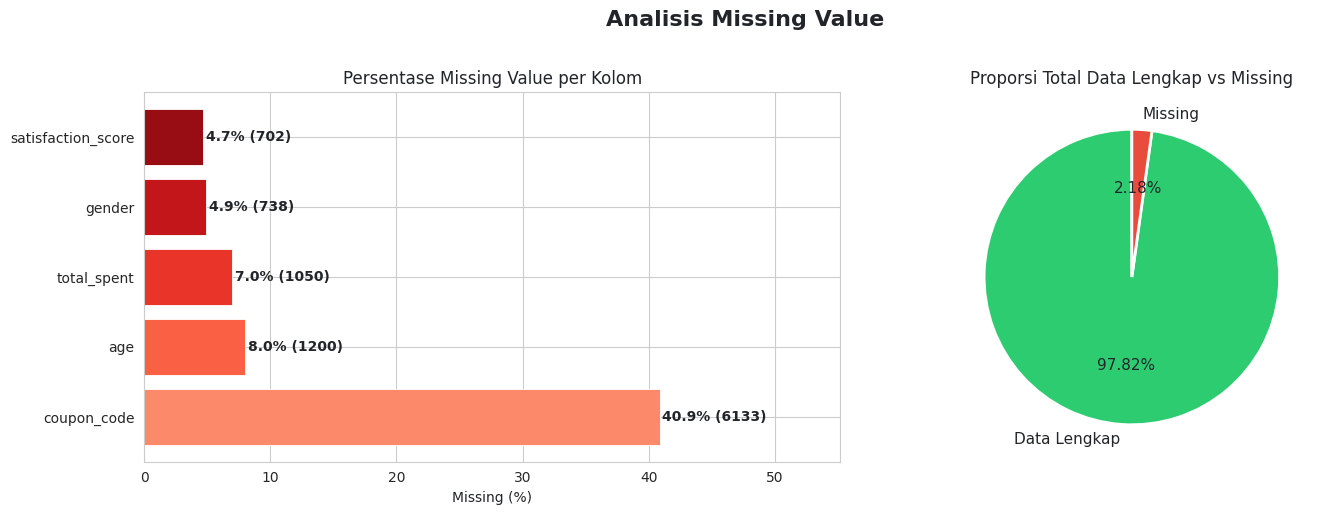


📋 Detail Missing Value:
                    Missing Count  Missing (%)
coupon_code                  6133    40.886667
age                          1200     8.000000
total_spent                  1050     7.000000
gender                        738     4.920000
satisfaction_score            702     4.680000


In [59]:
# Analisis Missing Value ─────────────────────────────────────────────
missing_count   = df.isnull().sum()
missing_percent = df.isnull().mean() * 100

missing = (pd.DataFrame({'Missing Count': missing_count, 'Missing (%)': missing_percent})
             .query('`Missing Count` > 0')
             .sort_values('Missing (%)', ascending=False))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle('Analisis Missing Value', fontsize=16, fontweight='bold',
             color='#212529', y=1.02)

# Bar chart horizontal
colors = plt.cm.Reds(np.linspace(0.4, 0.9, len(missing)))
bars = axes[0].barh(missing.index, missing['Missing (%)'],
                    color=colors, edgecolor='white', linewidth=0.6)
axes[0].set_title('Persentase Missing Value per Kolom', color='#212529', fontsize=12)
axes[0].set_xlabel('Missing (%)', color='#212529')
for bar, (_, row) in zip(bars, missing.iterrows()):
    axes[0].text(bar.get_width() + 0.2,
                 bar.get_y() + bar.get_height() / 2,
                 f'{row["Missing (%)"]:.1f}% ({int(row["Missing Count"])})',
                 va='center', fontsize=10, fontweight='bold', color='#212529')
axes[0].set_xlim(0, missing['Missing (%)'].max() * 1.35)

# Pie: proporsi keseluruhan
total_missing = missing['Missing Count'].sum()
total_ok      = df.size - total_missing
axes[1].pie([total_ok, total_missing],
            labels=['Data Lengkap', 'Missing'],
            colors=['#2ecc71', '#e74c3c'],
            autopct='%1.2f%%', startangle=90,
            wedgeprops={'edgecolor': '#ffffff', 'linewidth': 2},
            textprops={'color': '#212529', 'fontsize': 11})
axes[1].set_title('Proporsi Total Data Lengkap vs Missing', color='#212529', fontsize=12)

plt.tight_layout()
plt.show()

print('\n📋 Detail Missing Value:')
print(missing.to_string())


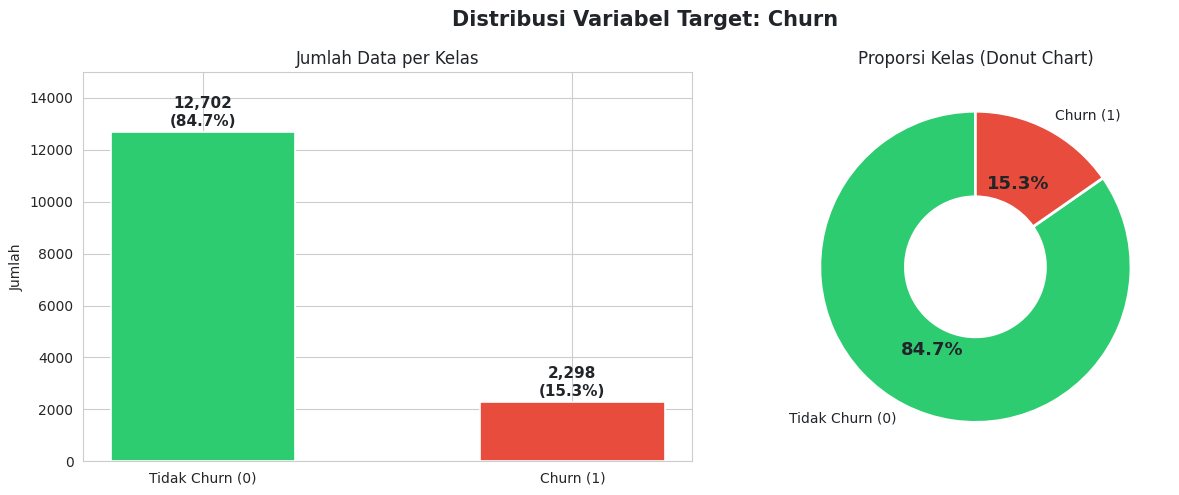

⚠️  Ketidakseimbangan kelas terdeteksi!
   Rasio Tidak Churn : Churn  =  5.5 : 1
   → Diperlukan penanganan imbalance (SMOTE) sebelum modeling.


In [60]:
# Distribusi Variabel Target: Churn ─────────────────────────────────
churn_counts = df['churn'].value_counts().sort_index()
labels       = ['Tidak Churn (0)', 'Churn (1)']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Distribusi Variabel Target: Churn',
             fontsize=15, fontweight='bold', color='#212529')

# Bar chart
bars = axes[0].bar(labels, churn_counts.values,
                   color=PALETTE, edgecolor='white', linewidth=1.2, width=0.5)
axes[0].set_title('Jumlah Data per Kelas', color='#212529', fontsize=12)
axes[0].set_ylabel('Jumlah', color='#212529')
axes[0].set_ylim(0, churn_counts.max() * 1.18)
for bar, val in zip(bars, churn_counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 120,
                 f'{val:,}\n({val / len(df) * 100:.1f}%)',
                 ha='center', va='bottom', fontsize=11,
                 fontweight='bold', color='#212529')

# Donut chart
wedges, texts, autotexts = axes[1].pie(
    churn_counts.values, labels=labels, colors=PALETTE,
    autopct='%1.1f%%', startangle=90,
    wedgeprops={'width': 0.55, 'edgecolor': '#ffffff', 'linewidth': 2},
    textprops={'color': '#212529'}
)
for at in autotexts:
    at.set_fontsize(13)
    at.set_fontweight('bold')
axes[1].set_title('Proporsi Kelas (Donut Chart)', color='#212529', fontsize=12)

plt.tight_layout()
plt.show()

ratio = churn_counts[0] / churn_counts[1]
print(f'⚠️  Ketidakseimbangan kelas terdeteksi!')
print(f'   Rasio Tidak Churn : Churn  =  {ratio:.1f} : 1')
print(f'   → Diperlukan penanganan imbalance (SMOTE) sebelum modeling.')

Kolom numerik yang dianalisis (19): ['age', 'is_premium_user', 'total_visits', 'avg_session_time', 'pages_per_session', 'email_open_rate', 'email_click_rate', 'total_spent', 'avg_order_value', 'discount_used', 'support_tickets', 'refund_requested', 'delivery_delay_days', 'satisfaction_score', 'nps_score', 'marketing_spend_per_user', 'lifetime_value', 'last_3_month_purchase_freq', 'churn']


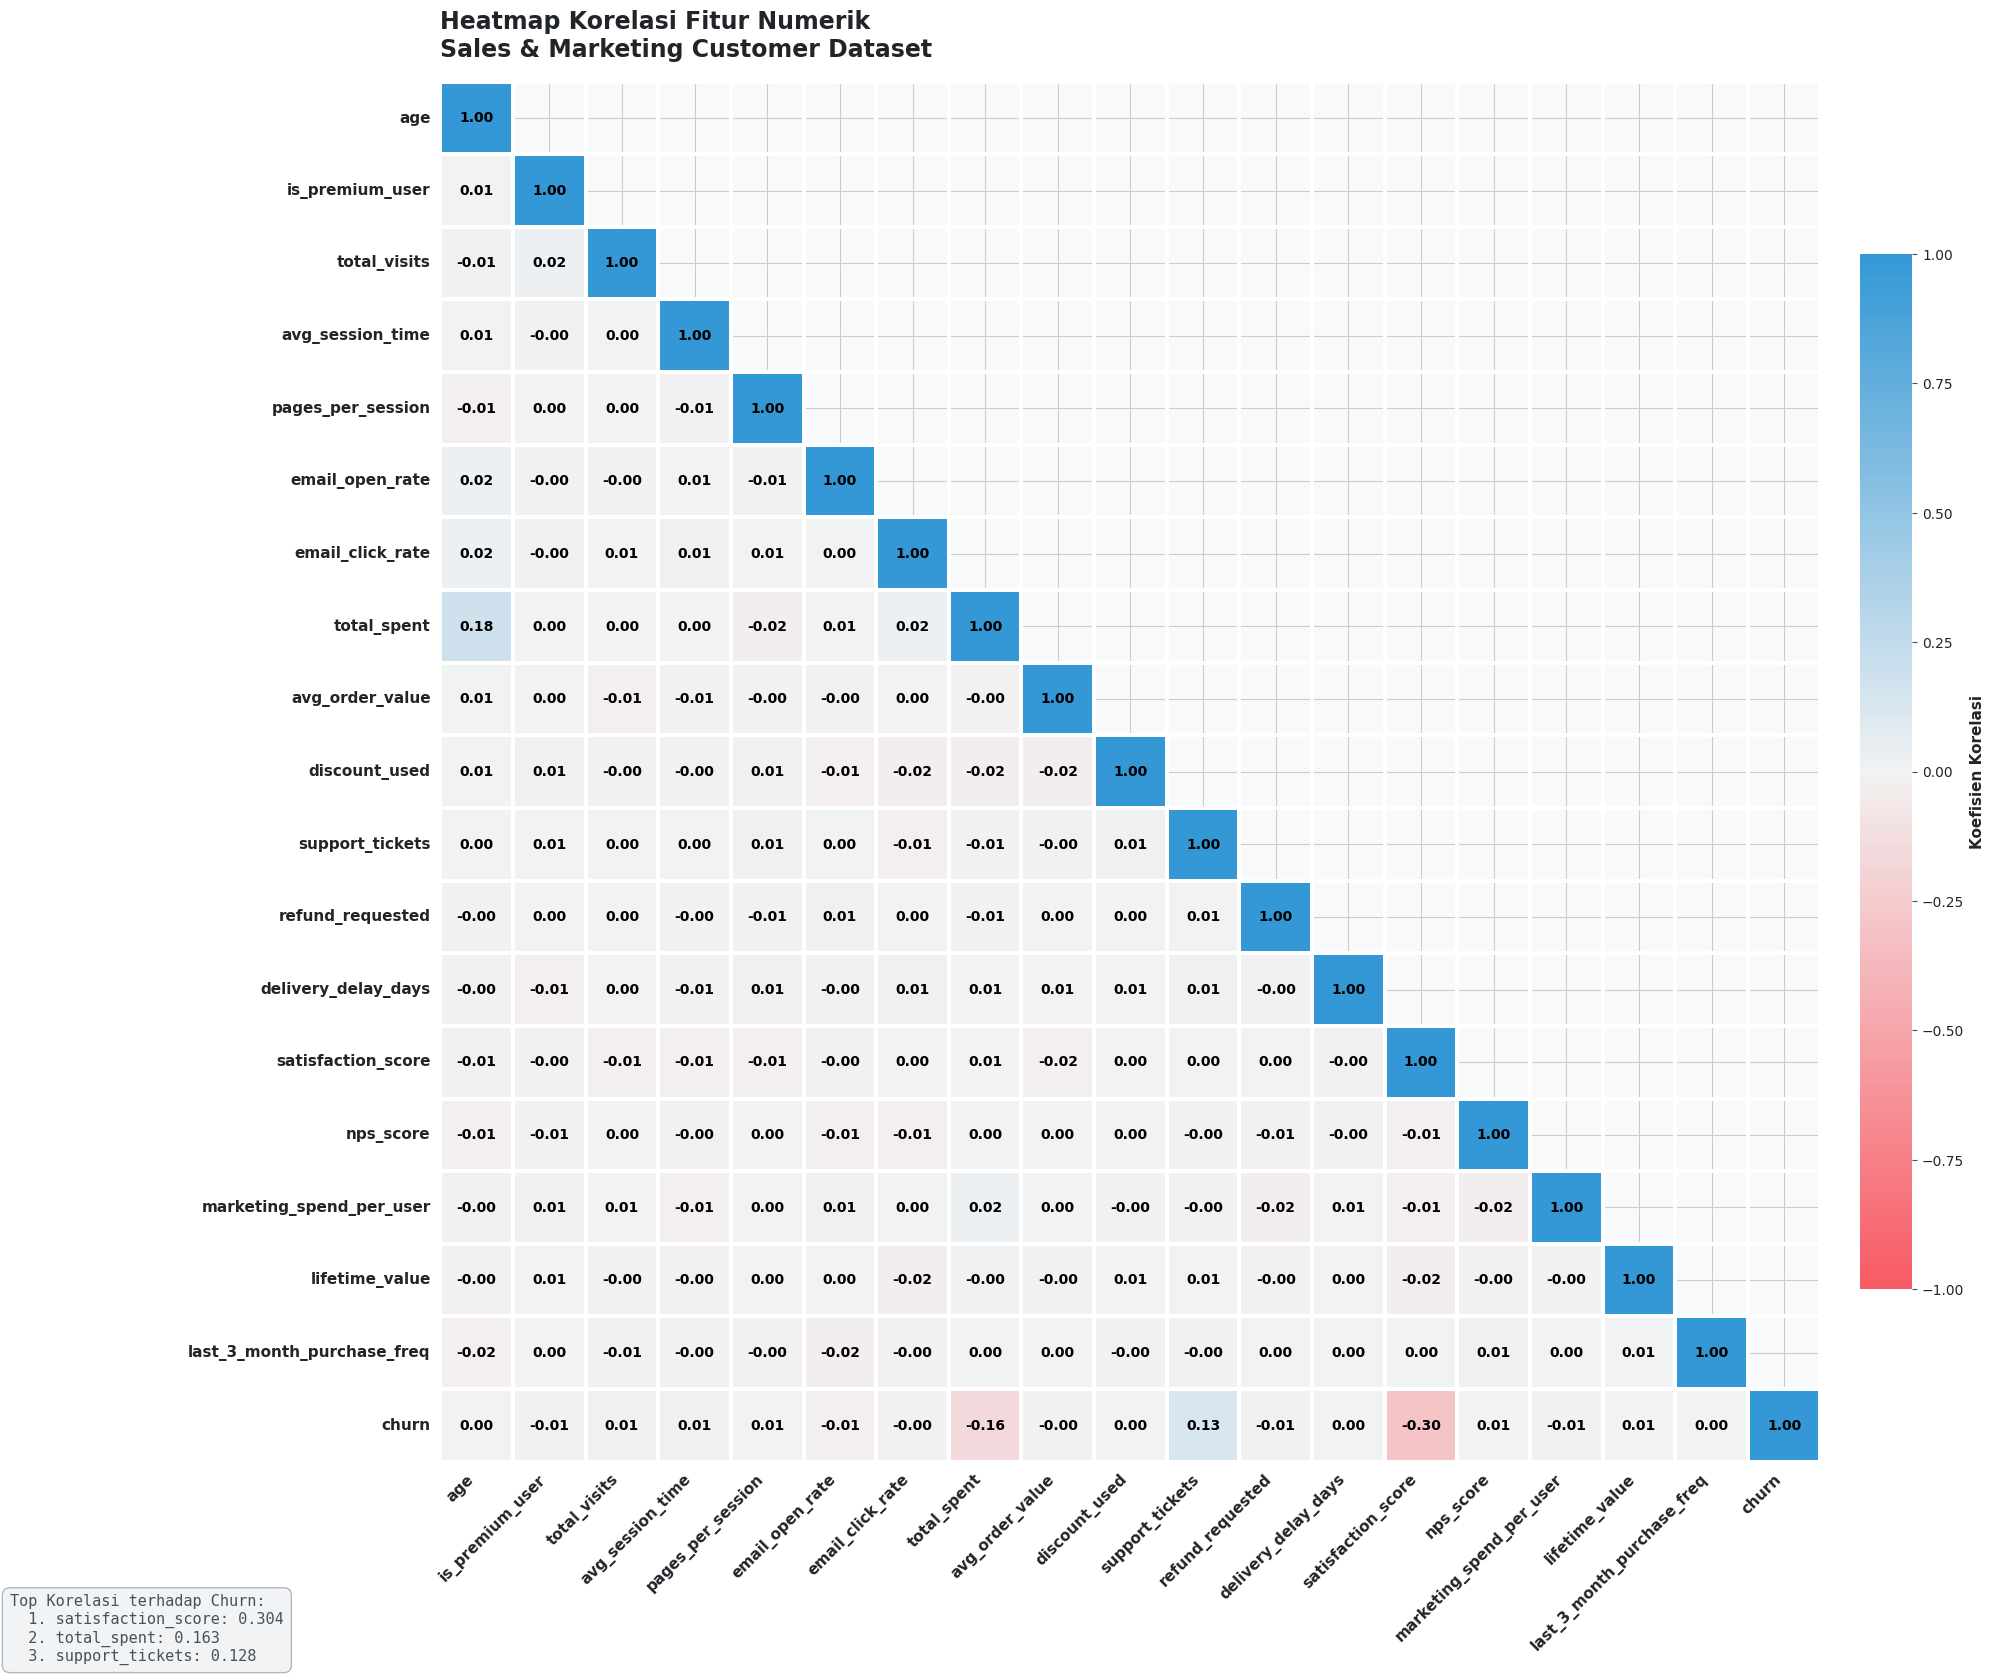


🏅 Top 10 Fitur Berkorelasi Paling Tinggi terhadap Churn:
─────────────────────────────────────────────
   1. satisfaction_score                  0.3036  █████████
   2. total_spent                         0.1633  ████
   3. support_tickets                     0.1279  ███
   4. total_visits                        0.0132  
   5. avg_session_time                    0.0122  
   6. email_open_rate                     0.0084  
   7. marketing_spend_per_user            0.0073  
   8. refund_requested                    0.0070  
   9. lifetime_value                      0.0063  
  10. pages_per_session                   0.0059  


In [61]:
# Heatmap Korelasi ───────────────────────────────────────────────────
num_cols = [c for c in df.select_dtypes(include=[np.number]).columns if c != 'customer_id']
print(f'Kolom numerik yang dianalisis ({len(num_cols)}): {num_cols}')

corr_matrix = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(22, 17))
fig.patch.set_facecolor('#ffffff')
ax.set_facecolor('#f8f9fa')

mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
cmap = sns.diverging_palette(10, 240, s=90, l=60, as_cmap=True)

hm = sns.heatmap(
    corr_matrix,
    mask=mask,
    cmap=cmap,
    vmax=1.0, vmin=-1.0, center=0,
    annot=True,
    fmt='.2f',
    annot_kws={'size': 10, 'weight': 'bold', 'color': 'black'},
    square=True,
    linewidths=1.5,
    linecolor='#ffffff',
    ax=ax,
    cbar_kws={'shrink': 0.75, 'label': 'Koefisien Korelasi', 'pad': 0.02}
)

ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right',
                   fontsize=11, fontweight='bold', color='#212529')
ax.set_yticklabels(ax.get_yticklabels(), rotation=0,
                   fontsize=11, fontweight='bold', color='#212529')

cbar = hm.collections[0].colorbar
cbar.ax.yaxis.set_tick_params(color='#495057', labelsize=10)
cbar.set_label('Koefisien Korelasi', color='#212529', fontsize=11, fontweight='bold')
plt.setp(cbar.ax.yaxis.get_ticklabels(), color='#212529')

ax.set_title('Heatmap Korelasi Fitur Numerik\nSales & Marketing Customer Dataset',
             fontsize=17, fontweight='bold', color='#212529', pad=18, loc='left')

churn_corr = corr_matrix['churn'].drop('churn').abs().sort_values(ascending=False)
top3_text  = 'Top Korelasi terhadap Churn:\n' + '\n'.join(
    [f'  {i+1}. {f}: {v:.3f}' for i, (f, v) in enumerate(churn_corr.head(3).items())]
)
fig.text(0.01, 0.01, top3_text, fontsize=11, color='#495057',
         va='bottom', ha='left', fontfamily='monospace',
         bbox=dict(boxstyle='round,pad=0.5', facecolor='#f1f3f5',
                   edgecolor='#adb5bd', alpha=0.95))

plt.tight_layout(pad=2.0)
plt.show()

print('\n🏅 Top 10 Fitur Berkorelasi Paling Tinggi terhadap Churn:')
print('─' * 45)
for rank, (feat, val) in enumerate(churn_corr.head(10).items(), 1):
    bar = '█' * int(val * 30)
    print(f'  {rank:>2}. {feat:<35} {val:.4f}  {bar}')


# 2. Direct Modeling

In [62]:
from sklearn.model_selection import train_test_split

# Memilih hanya data numerik dan membuang baris yang memiliki missing value sebagai baseline direct modeling
df_direct = df.select_dtypes(include=['float64', 'int64']).dropna()

# Menetapkan target (y) dan fitur (X), lalu Train-Test Split
X_dir = df_direct.drop(['churn', 'customer_id'], axis=1)
y_dir = df_direct['churn']

X_train_d, X_test_d, y_train_d, y_test_d = train_test_split(X_dir, y_dir, test_size=0.2, random_state=42, stratify=y_dir)

Evaluasi Model: KNN (Direct Modeling)
Accuracy : 0.8376
Precision: 0.4778
Recall   : 0.2494
F1-Score : 0.3277
Confusion Matrix:
[[1955  106]
 [ 292   97]]



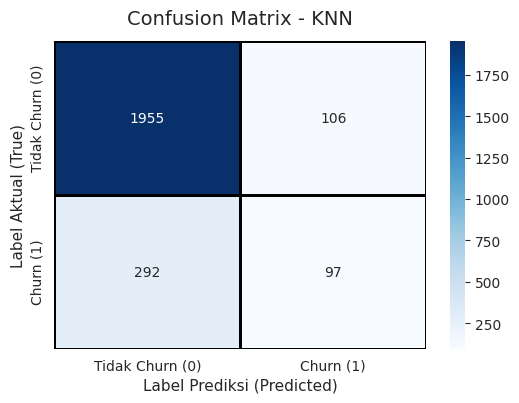

------------------------------------------------------------



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Evaluasi Model: Logistic Regression (Direct Modeling)
Accuracy : 0.8445
Precision: 0.5339
Recall   : 0.1620
F1-Score : 0.2485
Confusion Matrix:
[[2006   55]
 [ 326   63]]



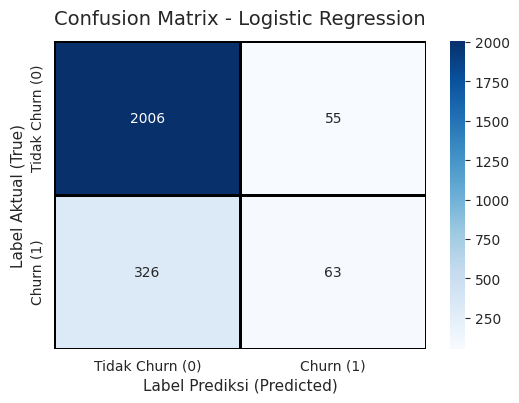

------------------------------------------------------------

Evaluasi Model: Naive Bayes (Direct Modeling)
Accuracy : 0.8359
Precision: 0.4656
Recall   : 0.2262
F1-Score : 0.3045
Confusion Matrix:
[[1960  101]
 [ 301   88]]



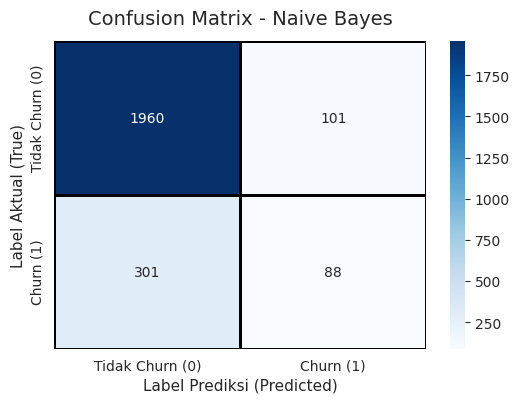

------------------------------------------------------------

Evaluasi Model: Random Forest (Direct Modeling)
Accuracy : 0.8376
Precision: 0.4863
Recall   : 0.4113
F1-Score : 0.4457
Confusion Matrix:
[[1892  169]
 [ 229  160]]



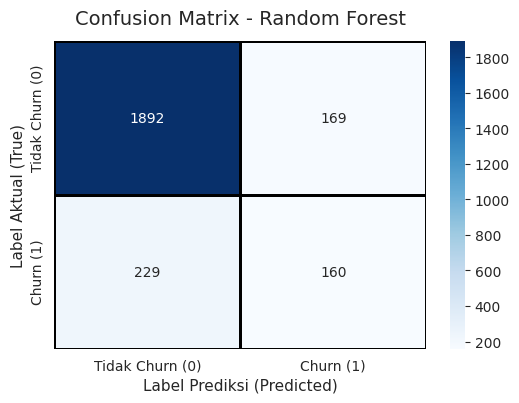

------------------------------------------------------------



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Evaluasi Model: Voting Classifier (Direct Modeling)
Accuracy : 0.8449
Precision: 0.5421
Recall   : 0.1491
F1-Score : 0.2339
Confusion Matrix:
[[2012   49]
 [ 331   58]]



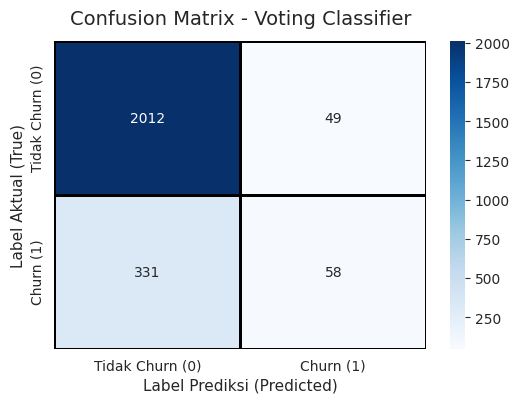

------------------------------------------------------------



In [63]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB # Import this module
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Mendefinisikan Model
knn = KNeighborsClassifier()
rf = RandomForestClassifier(random_state=42)
nb = GaussianNB()
logreg = LogisticRegression(max_iter=5000) # Increased max_iter to 5000

voting_clf = VotingClassifier(
    estimators=[('lr', logreg), ('nb', nb), ('knn', knn)],
    voting='hard'
)

models = {
    'KNN': knn,
    'Logistic Regression': logreg,
    'Naive Bayes': nb,
    'Random Forest': rf,
    'Voting Classifier': voting_clf
}

# Melatih dan Mengevaluasi Model secara langsung
for name, model in models.items():
    model.fit(X_train_d, y_train_d)
    y_pred = model.predict(X_test_d)

    print(f"Evaluasi Model: {name} (Direct Modeling)")
    print(f"Accuracy : {accuracy_score(y_test_d, y_pred):.4f}")
    print(f"Precision: {precision_score(y_test_d, y_pred, zero_division=0):.4f}")
    print(f"Recall   : {recall_score(y_test_d, y_pred, zero_division=0):.4f}")
    print(f"F1-Score : {f1_score(y_test_d, y_pred, zero_division=0):.4f}")
    print(f"Confusion Matrix:\n{confusion_matrix(y_test_d, y_pred)}\n")

# Menggambar Confusion Matrix untuk setiap model
    cm = confusion_matrix(y_test_d, y_pred)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=1, linecolor='black',
                xticklabels=['Tidak Churn (0)', 'Churn (1)'],
                yticklabels=['Tidak Churn (0)', 'Churn (1)'])

# Nama model disisipkan ke dalam judul agar tidak tertukar
    plt.title(f'Confusion Matrix - {name}', fontsize=14, pad=12)
    plt.xlabel('Label Prediksi (Predicted)', fontsize=11)
    plt.ylabel('Label Aktual (True)', fontsize=11)

    plt.show()

# Menampilkan grafik
    print("-" * 60 + "\n")

# 3. Modeling Dengan Preprocessing

In [64]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier # Added import
from sklearn.ensemble import RandomForestClassifier, VotingClassifier # Added import
from sklearn.linear_model import LogisticRegression # Added import
from sklearn.naive_bayes import GaussianNB # Added import

# =====================================================================
# DATA CADANGAN UNTUK BANDINGAN (Sebelum Preprocessing)
# =====================================================================
df_mentah = df.copy()
df_prep = df.copy()

 ANALISIS PERBANDINGAN SEBELUM VS SESUDAH PREPROCESSING 
1. Dimensi Data (Baris, Kolom):
 - Sebelum Preprocessing : (15000, 30)
 - Sesudah Preprocessing : (15000, 44) -> (Kolom bertambah karena One-Hot Encoding)
 - Jumlah Duplikasi Data Terhapus : 0 baris

2. Total Missing Value di Seluruh Dataset:
 - Sebelum Preprocessing : 9823 nilai kosong
 - Sesudah Preprocessing : 0 nilai kosong (Sukses diisi)

3. Penanganan Outlier menggunakan metode IQR - Capping:
--- Memeriksa Outlier Sebelum Capping ---
📌 Kolom 'age' memiliki 218 baris outlier.
📌 Kolom 'total_visits' memiliki 39 baris outlier.
📌 Kolom 'avg_session_time' memiliki 45 baris outlier.
📌 Kolom 'pages_per_session' memiliki 33 baris outlier.
📌 Kolom 'total_spent' memiliki 119 baris outlier.
📌 Kolom 'avg_order_value' memiliki 54 baris outlier.
📌 Kolom 'support_tickets' memiliki 79 baris outlier.
📌 Kolom 'refund_requested' memiliki 2215 baris outlier.
📌 Kolom 'delivery_delay_days' memiliki 184 baris outlier.
📌 Kolom 'satisfaction_score'

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:718: UserWarning: Using the boxplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


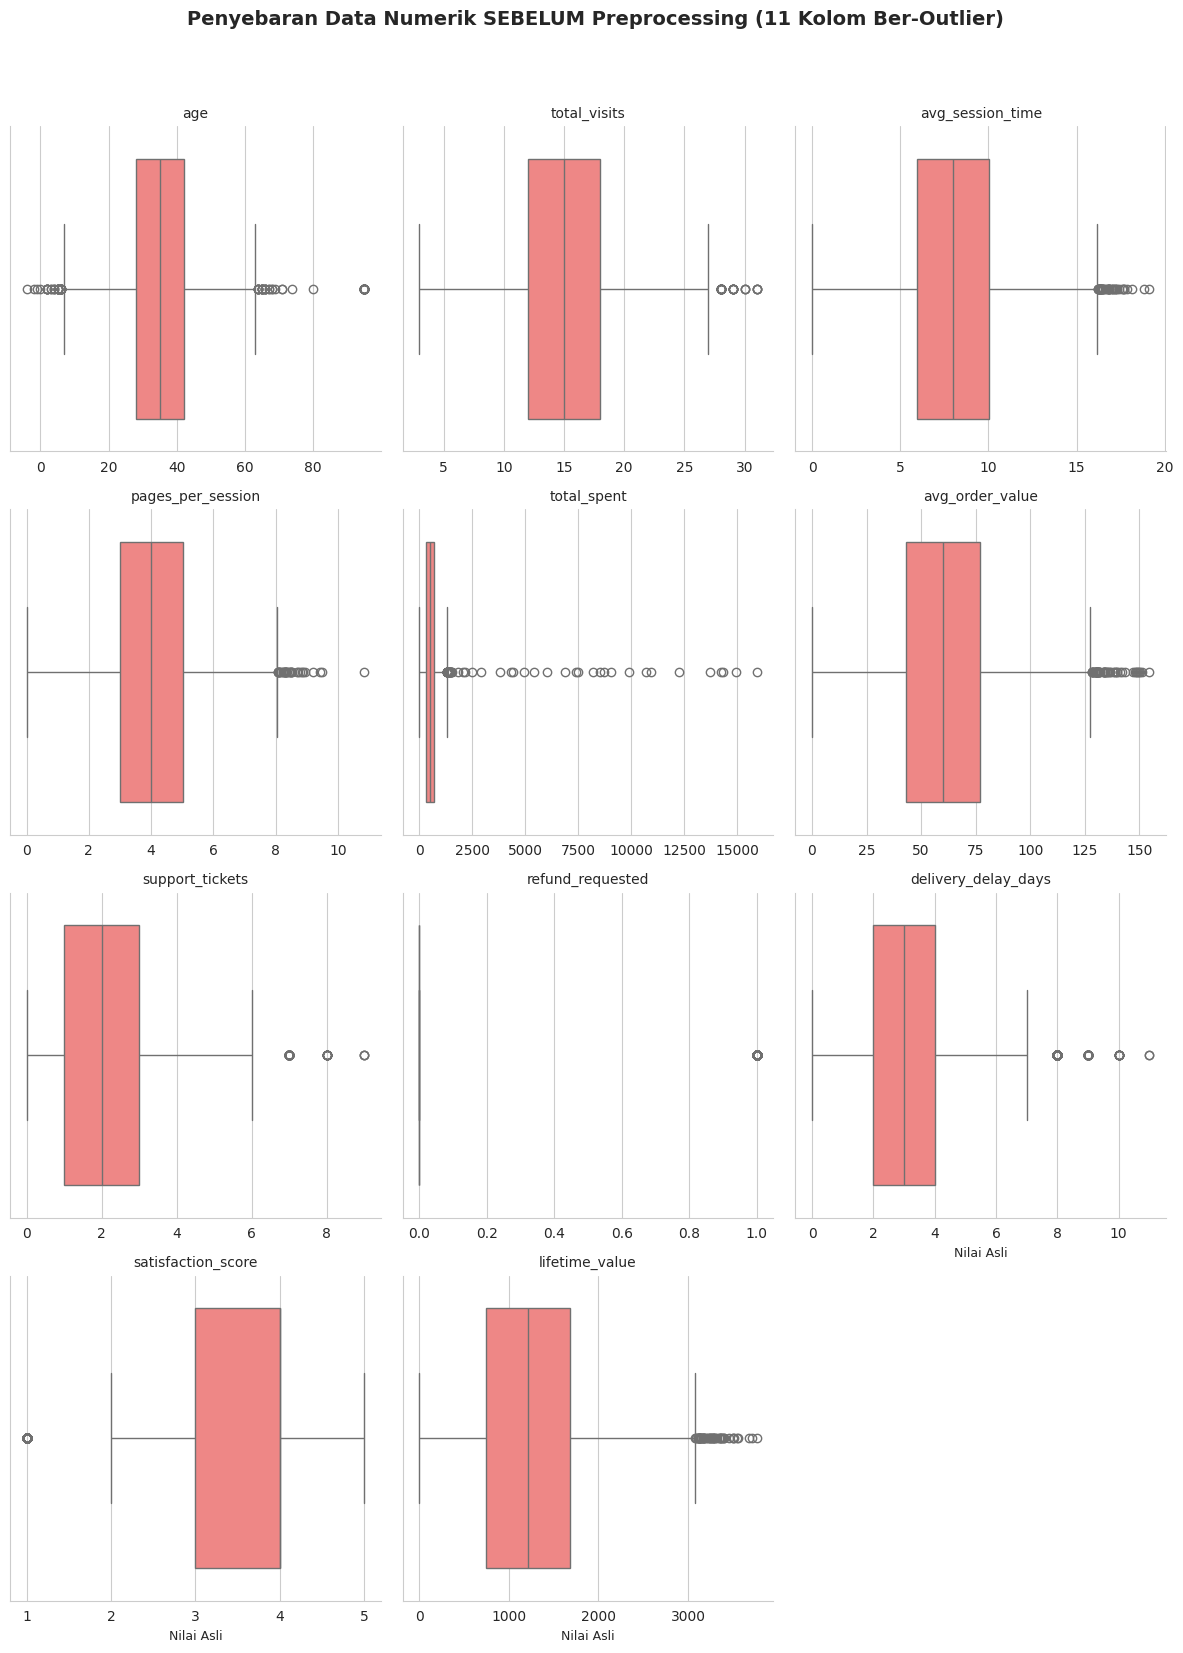

/usr/local/lib/python3.12/dist-packages/seaborn/axisgrid.py:718: UserWarning: Using the boxplot function without specifying `order` is likely to produce an incorrect plot.
  warnings.warn(warning)


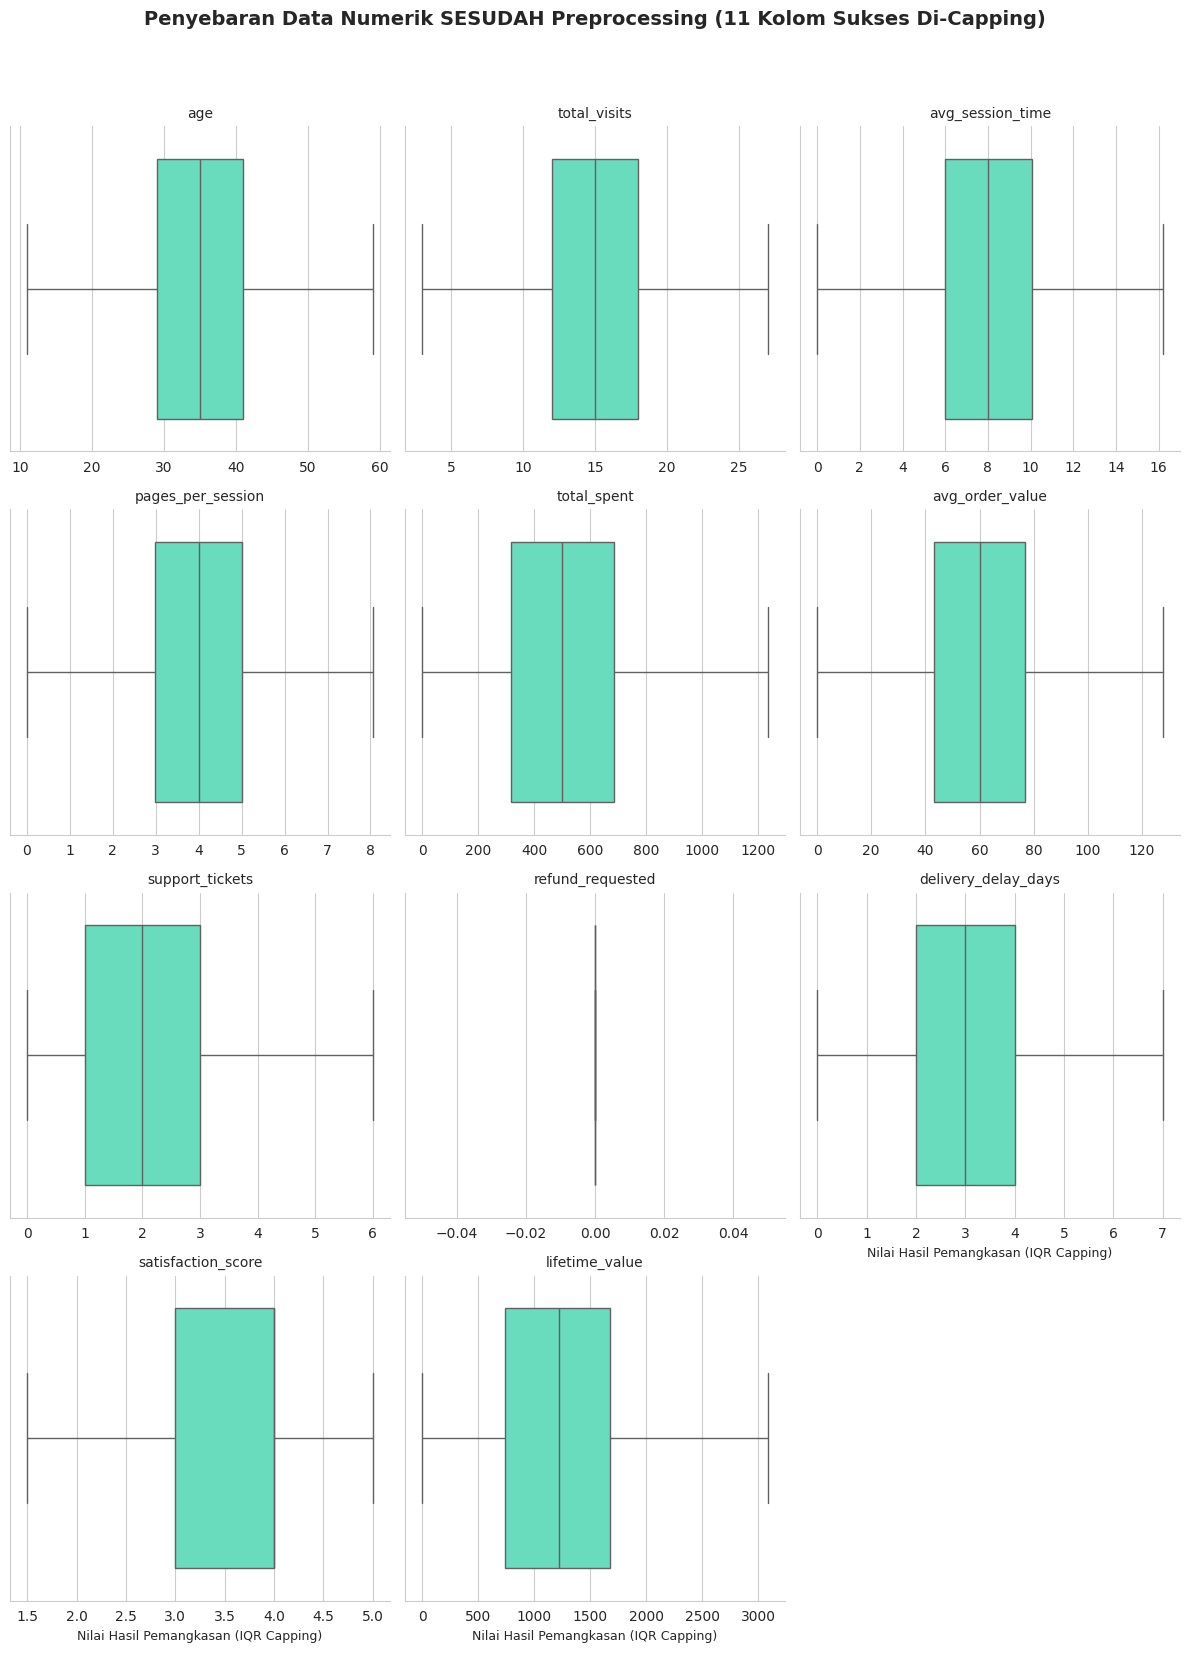


 3 Baris Pertama SEBELUM Preprocessing (Masih ada Teks & ID):
   customer_id  gender   age  country    city          signup_date   last_purchase_date acquisition_channel device_type subscription_type  is_premium_user  total_visits  avg_session_time  pages_per_session  email_open_rate  email_click_rate  total_spent  avg_order_value  discount_used coupon_code  support_tickets  refund_requested  delivery_delay_days payment_method  satisfaction_score  nps_score  marketing_spend_per_user  lifetime_value  last_3_month_purchase_freq  churn
0        10001    Male  52.0    India  Berlin  2022-05-10 00:00:00  2024-12-31 00:00:00               Email      Tablet            Annual                1             7         13.903745           5.415164             0.67              0.26   559.524958        65.246704              0       NEW20                0                 0                    3            UPI                 3.0         10                     27.56      915.310827                   

In [87]:
# =====================================================================
# 1. PREPROCESSING
# =====================================================================
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df_prep = df_mentah.copy() # biar df_mentah tetap utuh

# A. Hapus kolom tidak relevan
df_prep.drop(columns=['customer_id', 'signup_date', 'last_purchase_date'], inplace=True, errors='ignore')

# B. Hapus Duplikasi
dup_count = df_prep.duplicated().sum()
df_prep.drop_duplicates(inplace=True)

# C. Imputasi Missing Value
for col in df_prep.columns:
    if pd.api.types.is_numeric_dtype(df_prep[col]):
        df_prep[col] = df_prep[col].fillna(df_prep[col].median())
    else:
        df_prep[col] = df_prep[col].fillna(df_prep[col].mode()[0])

# D. One-Hot Encoding
cat_cols = df_prep.select_dtypes(include=['object', 'category']).columns.tolist()
df_prep = pd.get_dummies(df_prep, columns=cat_cols, drop_first=True)

# =====================================================================
# 📊 ANALISIS PERBANDINGAN SEBELUM VS SESUDAH PREPROCESSING
# =====================================================================
print("=" * 80)
print(" ANALISIS PERBANDINGAN SEBELUM VS SESUDAH PREPROCESSING ")
print("=" * 80)

# 1. Dimensi & Duplikasi
print(f"1. Dimensi Data (Baris, Kolom):")
print(f" - Sebelum Preprocessing : {df_mentah.shape}")
print(f" - Sesudah Preprocessing : {df_prep.shape} -> (Kolom bertambah karena One-Hot Encoding)")
print(f" - Jumlah Duplikasi Data Terhapus : {dup_count} baris")

# 2. Missing Value
print(f"\n2. Total Missing Value di Seluruh Dataset:")
print(f" - Sebelum Preprocessing : {df_mentah.isnull().sum().sum()} nilai kosong")
print(f" - Sesudah Preprocessing : {df_prep.isnull().sum().sum()} nilai kosong (Sukses diisi)")

# E. IQR Capping Outlier
print(f"\n3. Penanganan Outlier menggunakan metode IQR - Capping:")
num_cols = df_prep.select_dtypes(include=['number']).columns.tolist()
num_cols = [c for c in num_cols if c!= 'churn']

print("--- Memeriksa Outlier Sebelum Capping ---")
for col in num_cols:
    Q1, Q3 = df_prep[col].quantile([0.25, 0.75])
    IQR = Q3 - Q1
    lb, ub = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
    outlier_cnt = ((df_prep[col] < lb) | (df_prep[col] > ub)).sum()
    if outlier_cnt > 0:
        print(f"📌 Kolom '{col}' memiliki {outlier_cnt} baris outlier.")
    df_prep[col] = df_prep[col].clip(lower=lb, upper=ub)

# 3. VISUALISASI OUTLIER 11 KOLOM FIX
kolom_outlier_11 = [
    'age', 'total_visits', 'avg_session_time', 'pages_per_session',
    'total_spent', 'avg_order_value', 'support_tickets', 'refund_requested',
    'delivery_delay_days', 'satisfaction_score', 'lifetime_value'
]

df_mentah_plot = df_mentah.drop(columns=['customer_id', 'signup_date', 'last_purchase_date'], errors='ignore')
df_mentah_long = df_mentah_plot.melt(value_vars=kolom_outlier_11, var_name='Fitur', value_name='Nilai Mentah')
df_prep_long = df_prep.melt(value_vars=kolom_outlier_11, var_name='Fitur', value_name='Nilai Hasil Preprocess')

print("-" * 80)
print(" GRAFIK PERBANDINGAN OUTLIER SEBELUM & SESUDAH (11 KOLOM) ")
print("-" * 80)

# 3A. SEBELUM - Merah
sns.set_style("whitegrid")
g = sns.FacetGrid(df_mentah_long, col="Fitur", col_wrap=3, height=4, sharex=False, sharey=False)
g.map(sns.boxplot, "Nilai Mentah", color='#ff7675')
g.fig.suptitle("Penyebaran Data Numerik SEBELUM Preprocessing (11 Kolom Ber-Outlier)", fontsize=14, weight='bold', y=1.03)
g.set_titles("{col_name}", fontsize=11)
g.set_xlabels("Nilai Asli", fontsize=9)
plt.tight_layout()
plt.show()

print("\n" + "="*80 + "\n")

# 3B. SESUDAH - Hijau
g_p = sns.FacetGrid(df_prep_long, col="Fitur", col_wrap=3, height=4, sharex=False, sharey=False)
g_p.map(sns.boxplot, "Nilai Hasil Preprocess", color='#55efc4')
g_p.fig.suptitle("Penyebaran Data Numerik SESUDAH Preprocessing (11 Kolom Sukses Di-Capping)", fontsize=14, weight='bold', y=1.03)
g_p.set_titles("{col_name}", fontsize=11)
g_p.set_xlabels("Nilai Hasil Pemangkasan (IQR Capping)", fontsize=9)
plt.tight_layout()
plt.show()

# 4. Preview Data
print("\n 3 Baris Pertama SEBELUM Preprocessing (Masih ada Teks & ID):")
print(df_mentah.head(3).to_string()) # ganti display -> print

print("\n✨ 3 Baris Pertama SESUDAH Preprocessing (Siap Masuk Model / Semua Angka):")
print(df_prep.head(3).to_string()) # ganti display -> print
print("=" * 80 + "\n")

In [ ]:
RANDOM_STATE = 42 # Seed biar hasil split data selalu sama/reproducible

# Pisahkan fitur X dan target y
X = df_prep.drop(columns=['churn']) # Semua kolom kecuali 'churn' jadi fitur prediktor
y = df_prep['churn'] # Kolom 'churn' jadi target/label

# Cek jumlah fitur dan sampel
print(f'Fitur prediktor (X): {X.shape[1]} kolom') #.shape[1] = jumlah kolom
print(f'Variabel target (y): {y.shape[0]} sampel') #.shape[0] = jumlah baris

# Split data: 80% latih, 20% uji. Pakai stratify biar proporsi churn 0/1 tetap seimbang
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2, # 20% data untuk testing
    random_state=RANDOM_STATE, # Kunci random biar splitnya sama tiap run
    stratify=y # Jaga distribusi kelas y tetap sama di train & test
)

# Cek jumlah data setelah split
print(f'\nData Latih : {X_train.shape[0]} sampel') # Jumlah baris data training
print(f

In [68]:
#scaling (setelah split)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)   # Fit hanya pada data latih
X_test_scaled  = scaler.transform(X_test)         # Transform data uji

# Simpan nama kolom
feature_names = X.columns.tolist()
print(f'Scaling selesai! Shape train: {X_train_scaled.shape}')

Scaling selesai! Shape train: (12000, 43)


 Melatih Logistic Regression (Preprocessing)...
Evaluasi Model: Logistic Regression (Preprocessing)
Accuracy : 0.8453
Precision: 0.4870
Recall   : 0.1630
F1-Score : 0.2443
Confusion Matrix:
[[2461   79]
 [ 385   75]]



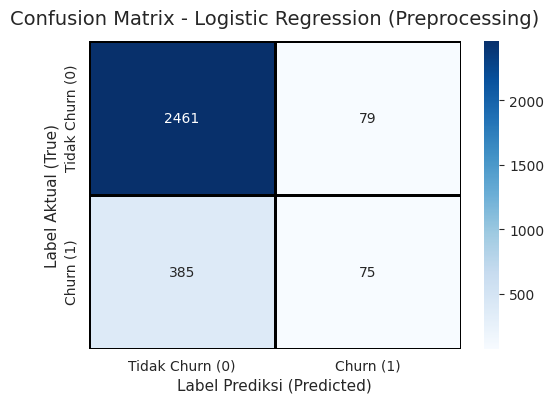

 Melatih Random Forest (Preprocessing)...
Evaluasi Model: Random Forest (Preprocessing)
Accuracy : 0.8523
Precision: 0.5459
Recall   : 0.2196
F1-Score : 0.3132
Confusion Matrix:
[[2456   84]
 [ 359  101]]



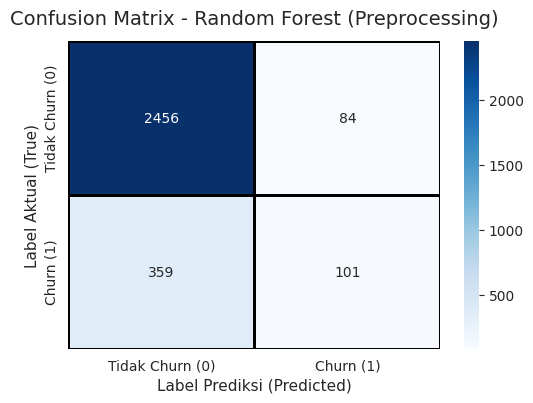

 Melatih Voting Classifier (Preprocessing)...
Evaluasi Model: Voting Classifier (LR+KNN+RF) (Preprocessing)
Accuracy : 0.8487
Precision: 0.5714
Recall   : 0.0522
F1-Score : 0.0956
Confusion Matrix:
[[2522   18]
 [ 436   24]]



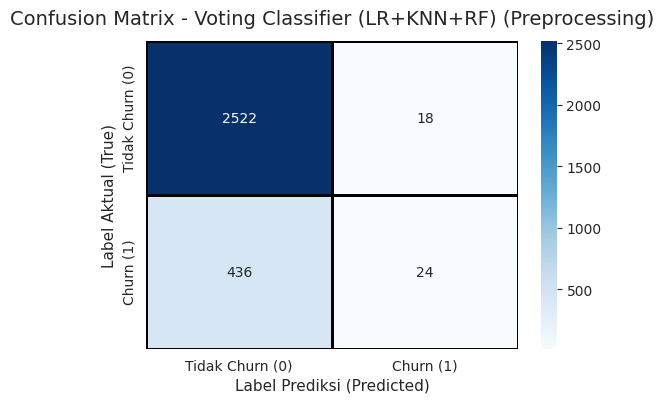

In [69]:
# =====================================================================
# 4 & 5. Melatih Model & Mengevaluasi dengan Metrik + Confusion Matrix
# =====================================================================
def evaluate_model(model, X_test, y_test, model_name="", scenario=""):
    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    cm = confusion_matrix(y_test, y_pred)

    print(f"Evaluasi Model: {model_name} ({scenario})")
    print(f"Accuracy : {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall   : {recall:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print(f"Confusion Matrix:\n{cm}\n")

    # Plot Confusion Matrix
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=1, linecolor='black',
                xticklabels=['Tidak Churn (0)', 'Churn (1)'],
                yticklabels=['Tidak Churn (0)', 'Churn (1)'])
    plt.title(f'Confusion Matrix - {model_name} ({scenario})', fontsize=14, pad=12)
    plt.xlabel('Label Prediksi (Predicted)', fontsize=11)
    plt.ylabel('Label Aktual (True)', fontsize=11)
    plt.show()

    return {
        'model_name': model_name,
        'scenario': scenario,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1_score': f1,
        'confusion_matrix': cm
    }


# ── Model 1: Logistic Regression ──────────────────────────
print(' Melatih Logistic Regression (Preprocessing)...')
lr_prep = LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)
lr_prep.fit(X_train_scaled, y_train)
result_lr_prep = evaluate_model(lr_prep, X_test_scaled, y_test,
                                 model_name='Logistic Regression', scenario='Preprocessing')

# ── Model 2: Random Forest ────────────────────────────────
print(' Melatih Random Forest (Preprocessing)...')
rf_prep = RandomForestClassifier(random_state=RANDOM_STATE, n_jobs=-1)
rf_prep.fit(X_train_scaled, y_train)
result_rf_prep = evaluate_model(rf_prep, X_test_scaled, y_test,
                                 model_name='Random Forest', scenario='Preprocessing')

# ── Model 3: Voting Classifier ────────────────────────────
print(' Melatih Voting Classifier (Preprocessing)...')
estimators_prep = [
    ('lr', LogisticRegression(random_state=RANDOM_STATE, max_iter=1000)),
    ('knn', KNeighborsClassifier(n_neighbors=7)),
    ('rf', RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1))
]
voting_prep = VotingClassifier(estimators=estimators_prep, voting='soft', n_jobs=-1)
voting_prep.fit(X_train_scaled, y_train)
result_voting_prep = evaluate_model(voting_prep, X_test_scaled, y_test,
                                     model_name='Voting Classifier (LR+KNN+RF)', scenario='Preprocessing')

# 4. Hyperparameter Tuning dan Feature Selection

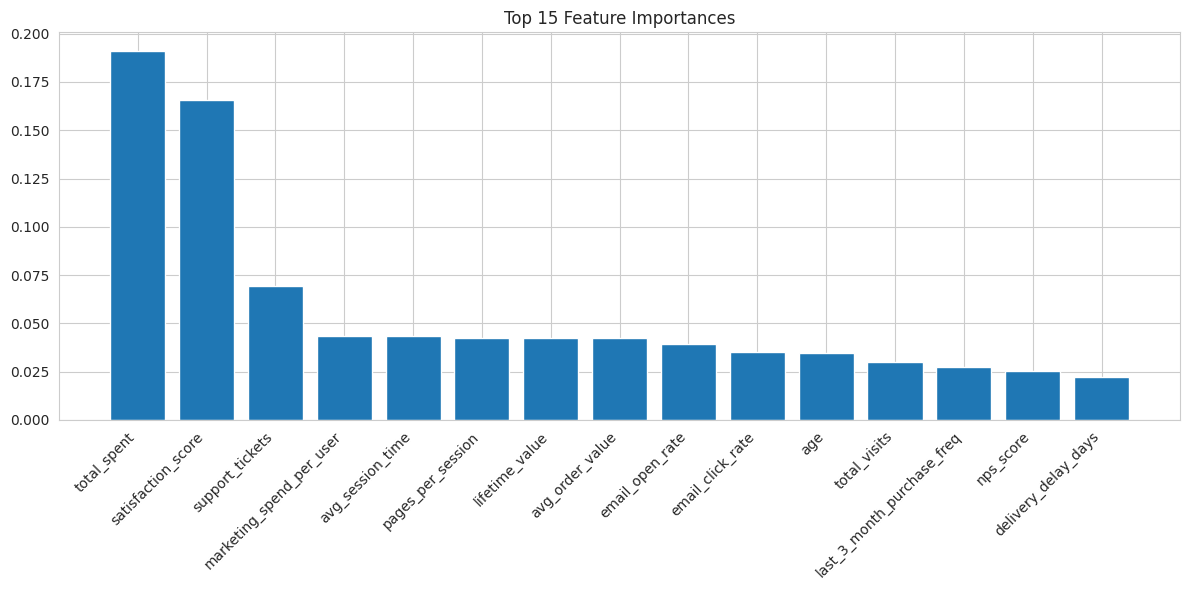

In [70]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier
import numpy as np
import matplotlib.pyplot as plt

# 1. Analisis Feature Importance (menggunakan Random Forest yang sudah ditraining sebelumnya)
rf_prep = RandomForestClassifier(random_state=42)
rf_prep.fit(X_train_scaled, y_train)

importances = rf_prep.feature_importances_
indices = np.argsort(importances)[::-1]

# Visualisasi 15 fitur paling berpengaruh
plt.figure(figsize=(12, 6)) # naikin width dikit biar 15 label nggak ketumpuk
plt.title("Top 15 Feature Importances")
plt.bar(range(15), importances[indices][:15], align="center")
plt.xticks(range(15), X.columns[indices][:15], rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [71]:
# 2. Menyusun Parameter Grid untuk Random Forest
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

# 3. Proses Hyperparameter Tuning menggunakan GridSearchCV
base_rf = RandomForestClassifier(random_state=42)

grid_search = GridSearchCV(
    estimator=base_rf,
    param_grid=param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train_scaled, y_train)

Fitting 3 folds for each of 36 candidates, totalling 108 fits


GridSearchCV(cv=3, estimator=RandomForestClassifier(random_state=42), n_jobs=-1,
             param_grid={'max_depth': [None, 10, 20],
                         'min_samples_leaf': [1, 2],
                         'min_samples_split': [2, 5],
                         'n_estimators': [50, 100, 200]},
             scoring='accuracy', verbose=1)


Best Parameters yang ditemukan: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Best CV Accuracy: 0.8502

--- Evaluasi Model: Random Forest (Setelah Tuning) ---
Accuracy : 0.8493
Precision: 0.5189
Recall : 0.2391
F1-Score : 0.3274


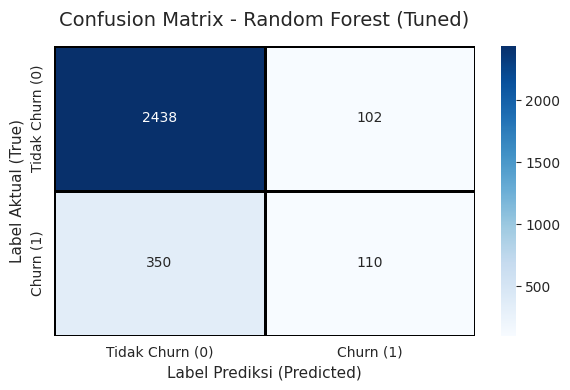

In [72]:
best_parameters = grid_search.best_params_
best_model = grid_search.best_estimator_ # ambil model terbaik yang udah di-refit
print(f"\nBest Parameters yang ditemukan: {best_parameters}")
print(f"Best CV Accuracy: {grid_search.best_score_:.4f}")

# 5. Evaluasi menggunakan model final dari GridSearchCV
y_pred_tuned = best_model.predict(X_test_scaled)

print("\n--- Evaluasi Model: Random Forest (Setelah Tuning) ---")
print(f"Accuracy : {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_tuned, zero_division=0):.4f}")
print(f"Recall : {recall_score(y_test, y_pred_tuned, zero_division=0):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred_tuned, zero_division=0):.4f}")

# --- MENGGAMBAR CONFUSION MATRIX ---
cm = confusion_matrix(y_test, y_pred_tuned)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=1, linecolor='black',
            xticklabels=['Tidak Churn (0)', 'Churn (1)'],
            yticklabels=['Tidak Churn (0)', 'Churn (1)'])

plt.title('Confusion Matrix - Random Forest (Tuned)', fontsize=14, pad=15)
plt.xlabel('Label Prediksi (Predicted)', fontsize=11)
plt.ylabel('Label Aktual (True)', fontsize=11)
plt.tight_layout()
plt.show()

Memulai Hyperparameter Tuning dengan RandomizedSearchCV scoring = accuracy...
Fitting 3 folds for each of 10 candidates, totalling 30 fits

Best Parameters yang ditemukan (Randomized): {'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 4, 'max_depth': 15}
Best CV Accuracy: 0.8512

Evaluasi Model: Random Forest (Setelah Randomized Tuning) ---
Accuracy : 0.8480
Precision: 0.5141
Recall : 0.1587
F1-Score : 0.2425


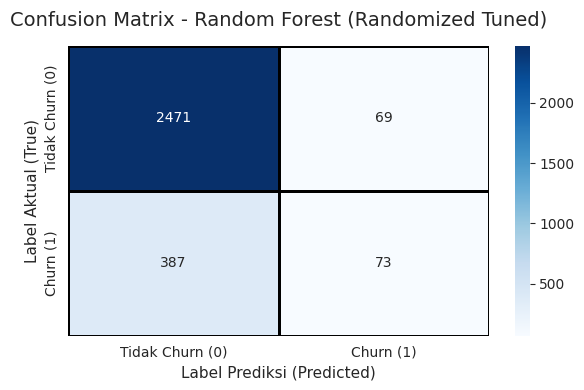

In [77]:
# Hyperparameter Tuning Random Forest - RandomizedSearchCV | metric: accuracy
from sklearn.model_selection import RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Baseline model, cuma jalanin sekali biar variabelnya kepake
_ = RandomForestClassifier(random_state=42, n_jobs=-1).fit(X_train_scaled, y_train)

# 2. Ruang pencarian parameter
grid_space = dict(
    n_estimators=[50, 100, 150, 200, 300],
    max_depth=[None, 10, 15, 20, 30],
    min_samples_split=[2, 5, 10],
    min_samples_leaf=[1, 2, 4]
)

print("Memulai Hyperparameter Tuning dengan RandomizedSearchCV scoring = accuracy...")
tuner = RandomizedSearchCV(
    RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=grid_space,
    n_iter=10,
    cv=3,
    scoring='accuracy',
    random_state=42,
    n_jobs=-1,
    verbose=1
)
tuner.fit(X_train_scaled, y_train)

# 3. Ambil model terbaik yang udah ke-refit otomatis
best_model = tuner.best_estimator_
print(f"\nBest Parameters yang ditemukan (Randomized): {tuner.best_params_}")
print(f"Best CV Accuracy: {tuner.best_score_:.4f}")

# 4. Evaluasi di test set
y_hat = best_model.predict(X_test_scaled)

print("\nEvaluasi Model: Random Forest (Setelah Randomized Tuning) ---")
print(f"Accuracy : {accuracy_score(y_test, y_hat):.4f}")
print(f"Precision: {precision_score(y_test, y_hat, zero_division=0):.4f}")
print(f"Recall : {recall_score(y_test, y_hat, zero_division=0):.4f}")
print(f"F1-Score : {f1_score(y_test, y_hat, zero_division=0):.4f}")

# 5. Confusion Matrix
cmx = confusion_matrix(y_test, y_hat)
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(cmx, annot=True, fmt='d', cmap='Blues', linewidths=1, linecolor='black', ax=ax,
            xticklabels=['Tidak Churn (0)', 'Churn (1)'],
            yticklabels=['Tidak Churn (0)', 'Churn (1)'])
ax.set_title('Confusion Matrix - Random Forest (Randomized Tuned)', fontsize=14, pad=15)
ax.set_xlabel('Label Prediksi (Predicted)', fontsize=11)
ax.set_ylabel('Label Aktual (True)', fontsize=11)
plt.tight_layout()
plt.show()

Memulai Hyperparameter Tuning dengan RandomizedSearchCV scoring = f1...
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Best Parameters yang ditemukan (Randomized): {'n_estimators': 300, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_depth': 10, 'class_weight': 'balanced'}
Best CV F1-Score: 0.6498

--- Evaluasi Model: Random Forest (Setelah Randomized Tuning) ---
Accuracy : 0.8553
Precision: 0.5150
Recall : 0.9696
F1-Score : 0.6727


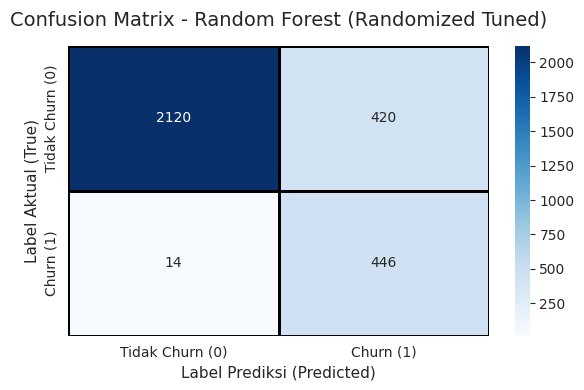

In [76]:
# Memulai Hyperparameter Tuning Random Forest dengan RandomizedSearchCV scoring = f1 score
from sklearn.model_selection import RandomizedSearchCV
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# Hapus rf_prep karena nggak dipakai. Langsung tuning aja.

# 1. Parameter Grid + class_weight
param_dist = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'class_weight': [None, 'balanced'] # <--- KUNCINYA
}

print("Memulai Hyperparameter Tuning dengan RandomizedSearchCV scoring = f1...")
rs = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42, n_jobs=-1),
    param_distributions=param_dist,
    n_iter=30,
    cv=5,
    scoring='f1',     # <--- TARGET F1-SCORE
    random_state=42,
    n_jobs=-1,
    verbose=1,
    refit=True        # <--- ini default True. Model terbaik auto di-fit ulang
)
rs.fit(X_train_p_scaled, y_train_p)

# 2. Ambil model terbaik langsung dari hasil refit
best_model = rs.best_estimator_
print(f"\nBest Parameters yang ditemukan (Randomized): {rs.best_params_}")
print(f"Best CV F1-Score : {rs.best_score_:.4f}")

# 3. Evaluasi menggunakan model best yang sudah refit
y_pred_tuned = best_model.predict(X_test_p_scaled)

print("\n--- Evaluasi Model: Random Forest (Setelah Randomized Tuning) ---")
print(f"Accuracy : {accuracy_score(y_test_p, y_pred_tuned):.4f}")
print(f"Precision: {precision_score(y_test_p, y_pred_tuned, zero_division=0):.4f}")
print(f"Recall : {recall_score(y_test_p, y_pred_tuned, zero_division=0):.4f}")
print(f"F1-Score : {f1_score(y_test_p, y_pred_tuned, zero_division=0):.4f}")

# 4. MENGGAMBAR CONFUSION MATRIX
cm = confusion_matrix(y_test_p, y_pred_tuned)

plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', linewidths=1, linecolor='black',
            xticklabels=['Tidak Churn (0)', 'Churn (1)'],
            yticklabels=['Tidak Churn (0)', 'Churn (1)'])

plt.title('Confusion Matrix - Random Forest (Randomized Tuned)', fontsize=14, pad=15)
plt.xlabel('Label Prediksi (Predicted)', fontsize=11)
plt.ylabel('Label Aktual (True)', fontsize=11)
plt.tight_layout()
plt.show()


Memulai Hyperparameter Tuning untuk KNN...
Fitting 3 folds for each of 20 candidates, totalling 60 fits

Best Parameters KNN yang ditemukan: {'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'distance'}
Best CV Accuracy : 0.8469

--- Evaluasi Model: KNN (Setelah Tuning) ---
Accuracy : 0.8463
Precision: 0.4615
Recall : 0.0130
F1-Score : 0.0254


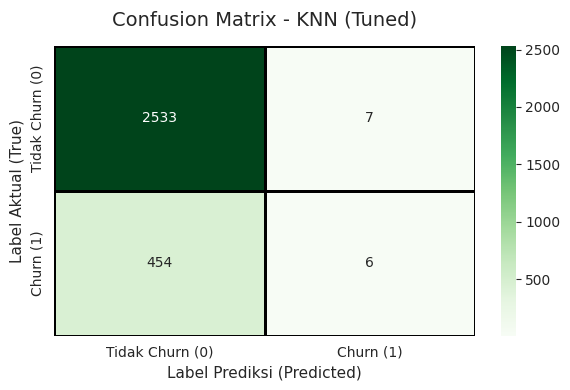

In [79]:
# Memulai Hyperparameter Tuning KNN dengan GridSearchCV
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("\n" + "="*60)
print("Memulai Hyperparameter Tuning untuk KNN...")
print("="*60)

# 1. Parameter Grid KNN
knn_space = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan']
}

# 2. GridSearchCV - refit=True default, jadi auto train ulang
gs_knn = GridSearchCV(
    estimator=KNeighborsClassifier(n_jobs=-1),
    param_grid=knn_space,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    refit=True
)
gs_knn.fit(X_train_scaled, y_train)

# 3. Ambil model terbaik yang udah ke-refit
knn_best = gs_knn.best_estimator_
print(f"\nBest Parameters KNN yang ditemukan: {gs_knn.best_params_}")
print(f"Best CV Accuracy : {gs_knn.best_score_:.4f}")

# 4. Evaluasi
y_pred_knn = knn_best.predict(X_test_scaled)

print("\n--- Evaluasi Model: KNN (Setelah Tuning) ---")
print(f"Accuracy : {accuracy_score(y_test, y_pred_knn):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_knn, zero_division=0):.4f}")
print(f"Recall : {recall_score(y_test, y_pred_knn, zero_division=0):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred_knn, zero_division=0):.4f}")

# 5. Confusion Matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(cm_knn, annot=True, fmt='d', cmap='Greens', linewidths=1, linecolor='black', ax=ax,
            xticklabels=['Tidak Churn (0)', 'Churn (1)'],
            yticklabels=['Tidak Churn (0)', 'Churn (1)'])
ax.set_title('Confusion Matrix - KNN (Tuned)', fontsize=14, pad=15)
ax.set_xlabel('Label Prediksi (Predicted)', fontsize=11)
ax.set_ylabel('Label Aktual (True)', fontsize=11)
plt.tight_layout()
plt.show()


Memulai Evaluasi Final Voting Classifier (Gabungan Model Tuned)...

--- Evaluasi Model: Voting Classifier Final (Tuned) ---
Accuracy : 0.8483
Precision: 0.5556
Recall : 0.0543
F1-Score : 0.0990


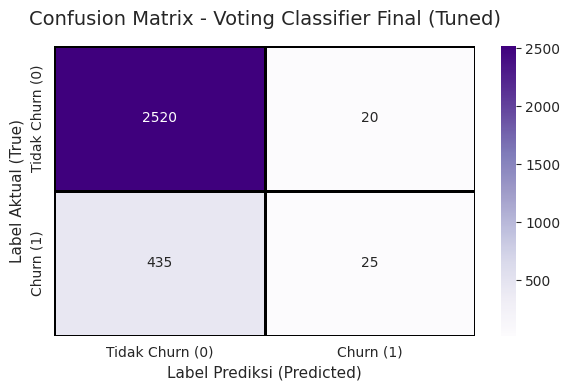

In [81]:
# --- EVALUASI VOTING CLASSIFIER FINAL (MODEL KE-9) ---
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

print("\n" + "="*60)
print("Memulai Evaluasi Final Voting Classifier (Gabungan Model Tuned)...")
print("="*60)

# 1. Susun base learners: LR baseline + RF tuned + KNN tuned
base_models = [
    ('lr', LogisticRegression(max_iter=1000, n_jobs=-1, random_state=42)),
    ('rf_tuned', best_model),   # ambil langsung dari hasil RandomizedSearchCV RF (scoring=f1)
    ('knn_tuned', knn_best)   # ambil langsung dari hasil GridSearchCV KNN
]

ensemble = VotingClassifier(estimators=base_models, voting='hard', n_jobs=-1)

# 2. Fit + Predict
ensemble.fit(X_train_scaled, y_train)
y_pred_ensemble = ensemble.predict(X_test_scaled)

# 3. Evaluasi
print("\n--- Evaluasi Model: Voting Classifier Final (Tuned) ---")
print(f"Accuracy : {accuracy_score(y_test, y_pred_ensemble):.4f}")
print(f"Precision: {precision_score(y_test, y_pred_ensemble, zero_division=0):.4f}")
print(f"Recall : {recall_score(y_test, y_pred_ensemble, zero_division=0):.4f}")
print(f"F1-Score : {f1_score(y_test, y_pred_ensemble, zero_division=0):.4f}")

# 4. Confusion Matrix
cm_ensemble = confusion_matrix(y_test, y_pred_ensemble)

plt.figure(figsize=(6, 4))
sns.heatmap(cm_ensemble, annot=True, fmt='d', cmap='Purples', linewidths=1, linecolor='black',
            xticklabels=['Tidak Churn (0)', 'Churn (1)'],
            yticklabels=['Tidak Churn (0)', 'Churn (1)'])

plt.title('Confusion Matrix - Voting Classifier Final (Tuned)', fontsize=14, pad=15)
plt.xlabel('Label Prediksi (Predicted)', fontsize=11)
plt.ylabel('Label Aktual (True)', fontsize=11)
plt.tight_layout()
plt.show()

In [84]:
# EVALUASI & PERBANDINGAN AKHIR 9 MODEL OTOMATIS
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB

# Fungsi bantuan untuk menghitung metrik
def ambil_metrik(y_true, y_pred):
    return [
        accuracy_score(y_true, y_pred),
        precision_score(y_true, y_pred, zero_division=0),
        recall_score(y_true, y_pred, zero_division=0),
        f1_score(y_true, y_pred, zero_division=0)
    ]

print("="*85)
print("             TABEL REKAPITULASI PERFORMA KESELURUHAN (9 MODEL OTOMATIS)             ")
print("="*85)

list_skor = []

# --- 1. Skenario 1: Direct Modeling ---
models_1 = [
    ('KNN (Model 1)', KNeighborsClassifier()),
    ('Random Forest (Model 2)', RandomForestClassifier(random_state=42, n_jobs=-1)),
    ('Voting Classifier (Model 3)', VotingClassifier(
        estimators=[
            ('lr', LogisticRegression(max_iter=5000, random_state=42, n_jobs=-1)),
            ('nb', GaussianNB()),
            ('knn', KNeighborsClassifier())
        ], voting='hard', n_jobs=-1)
    )
]
for nama, mdl in models_1:
    mdl.fit(X_train_d, y_train_d)
    list_skor.append(['1. Direct Modeling', nama] + ambil_metrik(y_test_d, mdl.predict(X_test_d)))

# --- 2. Skenario 2: Dengan Preprocessing ---
models_2 = [
    ('KNN (Model 4)', KNeighborsClassifier()),
    ('Random Forest (Model 5)', RandomForestClassifier(random_state=42, n_jobs=-1)),
    ('Voting Classifier (Model 6)', VotingClassifier(
        estimators=[
            ('lr', LogisticRegression(max_iter=5000, random_state=42, n_jobs=-1)),
            ('nb', GaussianNB()),
            ('knn', KNeighborsClassifier())
        ], voting='hard', n_jobs=-1)
    )
]
for nama, mdl in models_2:
    mdl.fit(X_train_scaled, y_train)
    list_skor.append(['2. Dengan Preprocessing', nama] + ambil_metrik(y_test, mdl.predict(X_test_scaled)))

# --- 3. Skenario 3: Hyperparameter Tuning ---
# 'best_model' is the tuned Random Forest from cell IttyqBWmCNRZ (tuned for F1-score)
# 'knn_best' is the tuned KNN from cell azA5rH-gFhh-
models_3 = [
    ('Random Forest Tuned (Model 7)', best_model),
    ('KNN Tuned (Model 8)', knn_best)
]
for nama, mdl in models_3:
    # These models are already fitted during their tuning process
    list_skor.append(['3. Hyperparameter Tuning', nama] + ambil_metrik(y_test, mdl.predict(X_test_scaled)))

# --- 4. Skenario 4: Final Voting Classifier ---
# 'ensemble' is the final Voting Classifier from cell JY9Sj6yBH2oI
models_4 = [
    ('Final Voting Classifier (Model 9)', ensemble)
]
for nama, mdl in models_4:
    # This model is already fitted
    list_skor.append(['4. Final Voting Classifier', nama] + ambil_metrik(y_test, mdl.predict(X_test_scaled)))

# --- Membuat DataFrame Hasil ---
df_results = pd.DataFrame(list_skor, columns=['Skenario', 'Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score'])
df_results_sorted = df_results.sort_values(by='F1-Score', ascending=False)

display(df_results_sorted)


             TABEL REKAPITULASI PERFORMA KESELURUHAN (9 MODEL OTOMATIS)             


,Skenario,Model,Accuracy,Precision,Recall,F1-Score
1,1. Direct Modeling,Random Forest (Model 2),0.837551,0.486322,0.411311,0.445682
0,1. Direct Modeling,KNN (Model 1),0.837551,0.477833,0.249357,0.327703
4,2. Dengan Preprocessing,Random Forest (Model 5),0.852333,0.545946,0.219565,0.313178
6,3. Hyperparameter Tuning,Random Forest Tuned (Model 7),0.848000,0.514085,0.158696,0.242525
2,1. Direct Modeling,Voting Classifier (Model 3),0.844898,0.542056,0.149100,0.233871
5,2. Dengan Preprocessing,Voting Classifier (Model 6),0.845333,0.482456,0.119565,0.191638
8,4. Final Voting Classifier,Final Voting Classifier (Model 9),0.848333,0.555556,0.054348,0.099010
3,2. Dengan Preprocessing,KNN (Model 4),0.841667,0.384615,0.054348,0.095238
7,3. Hyperparameter Tuning,KNN Tuned (Model 8),0.846333,0.461538,0.013043,0.025370


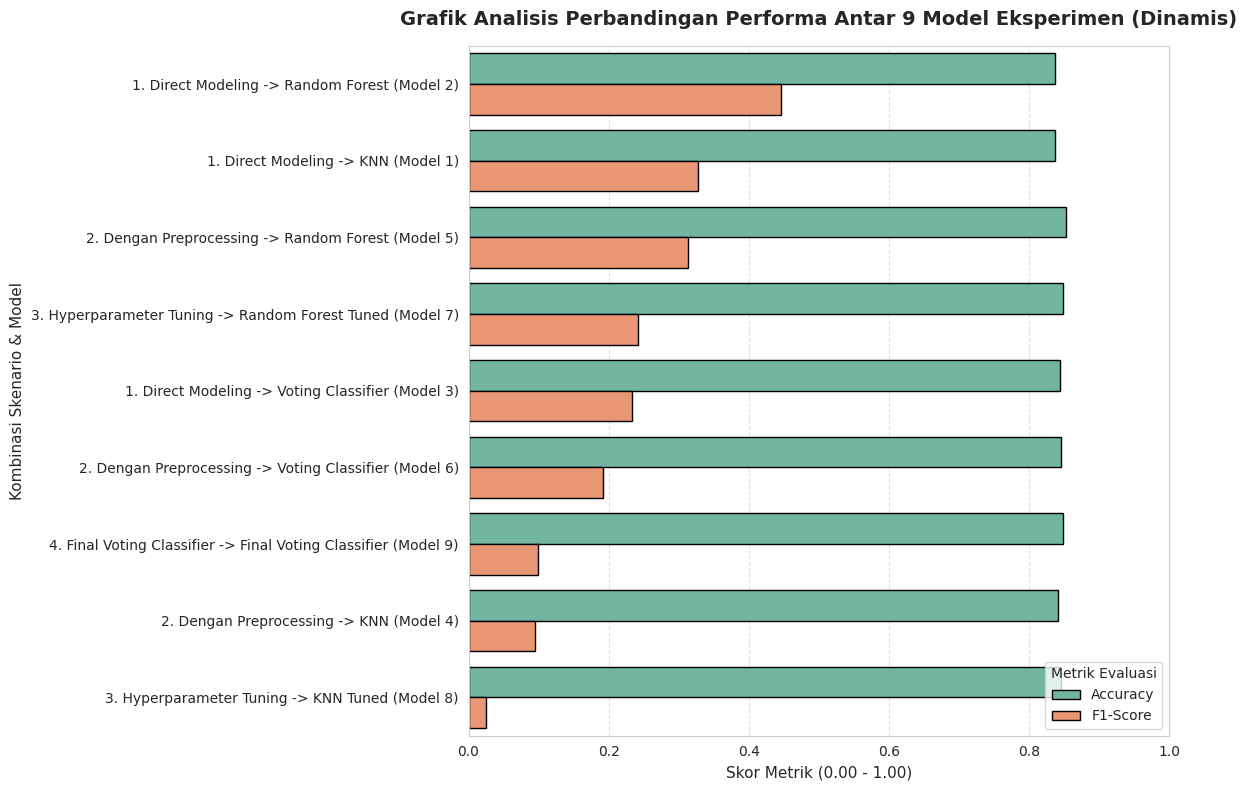

In [86]:
# --- VISUALISASI GRAFIK PERBANDINGAN PERFORMA (ACCURACY VS F1-SCORE) ---
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Ubah format df_perbandingan dari wide -> long
plot_df = df_results_sorted.melt(
    id_vars=['Skenario', 'Model'],
    value_vars=['Accuracy', 'F1-Score'],
    var_name='Metrik Evaluasi',
    value_name='Skor'
)

# 2. Gabung label biar 1 baris = 1 model
plot_df['Label Model'] = plot_df['Skenario'] + " -> " + plot_df['Model']

# 3. Plot
fig, ax = plt.subplots(figsize=(12, 8))
sns.barplot(
    data=plot_df,
    y='Label Model',        # sumbu Y
    x='Skor',               # sumbu X
    hue='Metrik Evaluasi',  # warna: Accuracy vs F1-Score
    palette='Set2',
    edgecolor='black',
    ax=ax,
    errorbar=None           # biar nggak ada garis errorbar bawaan seaborn baru
)

# 4. Setting tampilan biar sama persis
ax.set_title('Grafik Analisis Perbandingan Performa Antar 9 Model Eksperimen (Dinamis)',
             fontsize=14, pad=15, weight='bold')
ax.set_xlabel('Skor Metrik (0.00 - 1.00)', fontsize=11)
ax.set_ylabel('Kombinasi Skenario & Model', fontsize=11)
ax.set_xlim(0.0, 1.0)
ax.grid(axis='x', linestyle='--', alpha=0.6)
ax.legend(loc='lower right', title='Metrik Evaluasi')

fig.tight_layout()
plt.show()

# 5. Deployment

In [91]:
import joblib
import os

MODEL_FILENAME = 'model_churn_terbaik.pkl'

joblib.dump(best_model, MODEL_FILENAME)
joblib.dump(scaler, 'scaler.pkl')

print(f"Model disimpan: {MODEL_FILENAME}")
print(f"Scaler disimpan: scaler.pkl")
print(f"Ukuran: {os.path.getsize(MODEL_FILENAME)/1024:.2f} KB")

Model disimpan: model_churn_terbaik.pkl
Scaler disimpan: scaler.pkl
Ukuran: 3535.48 KB


In [92]:
%%writefile /content/app.py
import streamlit as st
import pandas as pd
import joblib

st.set_page_config(page_title="Prediksi Churn UAS", layout="wide")
st.title("📊 Prediksi Churn Pelanggan UAS")

# 1. Load Model + Scaler
model = joblib.load('model_churn_terbaik.pkl')
scaler = joblib.load('scaler.pkl')

# 2. WAJIB ISI INI DENGAN KOLOM KAMU
# Jalankan: print(X.columns.tolist()) di cell atas, lalu copy paste hasilnya ke sini
FEATURE_COLUMNS = [
    'age', 'total_visits', 'avg_session_time', 'pages_per_session',
    #...lanjutkan semua kolom dari X.columns kamu sampai habis
]

st.write("Isi semua fitur di bawah ini. Kategorikal: 0 atau 1.")

# 3. Input Form
input_data = {}
cols = st.columns(5)
for i, col in enumerate(FEATURE_COLUMNS):
    with cols[i % 5]:
        input_data[col] = st.number_input(col, value=0.0, format="%.4f", key=col)

if st.button("🔮 Prediksi Sekarang"):
    input_df = pd.DataFrame([input_data], columns=FEATURE_COLUMNS)
    input_scaled = scaler.transform(input_df)
    prediction = model.predict(input_scaled)

    if prediction[0] == 1:
        st.error("🚨 Hasil: PELANGGAN AKAN CHURN = 1")
    else:
        st.success("✅ Hasil: PELANGGAN TIDAK CHURN = 0")

Writing /content/app.py


In [93]:
%%writefile /content/requirements.txt
streamlit
pandas
scikit-learn
joblib
numpy
seaborn
matplotlib

Writing /content/requirements.txt
